In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import shap
from openpyxl import load_workbook

problem_name = 'qf'
model_name = 'rf'
sheet_name = 'qf_21'
data_file = '20240607FULL_final.xlsx'
shap_output_path = f'final_model/{problem_name}/{model_name}_shap_results.xlsx'
model_save_path = f'final_model/{problem_name}/{model_name}'


# 创建文件夹
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# 读取数据
kl_data = pd.read_excel(data_file, index_col=0, sheet_name=sheet_name)
X = kl_data.iloc[:, :-2]
y = kl_data['屈服强度']

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 交叉验证配置
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 模型训练和评估
index = 0
with pd.ExcelWriter(shap_output_path, engine='openpyxl') as writer:
    # 初始化最终结果的DataFrame
    final_original_values_df = pd.DataFrame()
    final_shap_values_df = pd.DataFrame()

    for train_index, test_index in skf.split(X, y_binned):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = RandomForestRegressor(random_state=60)
        model.fit(X_train, y_train)

        # joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # SHAP分析
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train)

        # 保存每个模型的原始值和SHAP值到单独的sheet
        original_sheet_name = f'Model_{index + 1}_Original'
        shap_sheet_name = f'Model_{index + 1}_SHAP'

        pd.DataFrame(X_train.values, columns=X_train.columns).to_excel(writer, sheet_name=original_sheet_name, index=False)
        pd.DataFrame(shap_values, columns=X_train.columns).to_excel(writer, sheet_name=shap_sheet_name, index=False)

        # 合并到最终结果DataFrame中
        original_values_df = pd.DataFrame(X_train.values, columns=X_train.columns)
        original_values_df['Model'] = model_name
        original_values_df['Fold'] = index + 1
        final_original_values_df = pd.concat([final_original_values_df, original_values_df], ignore_index=True)

        shap_values_df = pd.DataFrame(shap_values, columns=X_train.columns)
        shap_values_df['Model'] = model_name
        shap_values_df['Fold'] = index + 1
        final_shap_values_df = pd.concat([final_shap_values_df, shap_values_df], ignore_index=True)

        index += 1
        # 写入最终的原始值和SHAP值sheet
    final_original_values_df.to_excel(writer, sheet_name='Final_Original_Values', index=False)
    final_shap_values_df.to_excel(writer, sheet_name='Final_SHAP_Values', index=False)
print(f'SHAP results saved to {shap_output_path}')



import pandas as pd
import shap
import matplotlib.pyplot as plt

# 从Excel文件中读取最终的原始值和SHAP值数据
shap_output_path = 'final_model/qf/rf_shap_results.xlsx'
final_original_values_df = pd.read_excel(shap_output_path, sheet_name='Final_Original_Values').drop(columns=['MagpieData range MeltingT','MagpieData maximum MeltingT'])
final_shap_values_df = pd.read_excel(shap_output_path, sheet_name='Final_SHAP_Values').drop(columns=['MagpieData range MeltingT','MagpieData maximum MeltingT'])
display(final_original_values_df)
# 选择要绘制的特征名称
feature_to_plot = final_original_values_df.columns[:-2]

# 获取特定特征的原始值和SHAP值
original_values = final_original_values_df[feature_to_plot]
shap_values = final_shap_values_df[feature_to_plot]
plt.gcf().set_dpi(600)  # 设置dpi

# 使用shap.summary_plot函数绘制SHAP汇总图
shap.summary_plot(shap_values.values, original_values.values, feature_names=feature_to_plot,  show=False)
plt.gcf().set_size_inches(5, 8)  # 设置图像大小

plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小

plt.show()

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import shap
from openpyxl import load_workbook

problem_name = 'qf'
model_name = 'rf'
sheet_name = 'qf_21'
data_file = '20240607FULL_final.xlsx'
shap_output_path = f'final_model/{problem_name}/{model_name}_shap_results.xlsx'
model_save_path = f'final_model/{problem_name}/{model_name}'


# 创建文件夹
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# 读取数据
kl_data = pd.read_excel(data_file, sheet_name=sheet_name)
X = kl_data.iloc[:, :-2]
y = kl_data['屈服强度']

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 交叉验证配置
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 模型训练和评估
index = 0
with pd.ExcelWriter(shap_output_path, engine='openpyxl') as writer:
    # 初始化最终结果的DataFrame
    final_original_values_df = pd.DataFrame()
    final_shap_values_df = pd.DataFrame()

    for train_index, test_index in skf.split(X, y_binned):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = RandomForestRegressor(random_state=60)
        model.fit(X_train, y_train)

        # joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # SHAP分析
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train)

        # 保存每个模型的原始值和SHAP值到单独的sheet
        original_sheet_name = f'Model_{index + 1}_Original'
        shap_sheet_name = f'Model_{index + 1}_SHAP'

        pd.DataFrame(X_train.values, columns=X_train.columns).to_excel(writer, sheet_name=original_sheet_name, index=False)
        pd.DataFrame(shap_values, columns=X_train.columns).to_excel(writer, sheet_name=shap_sheet_name, index=False)

        # 合并到最终结果DataFrame中
        original_values_df = pd.DataFrame(X_train.values, columns=X_train.columns)
        original_values_df['Model'] = model_name
        original_values_df['Fold'] = index + 1
        final_original_values_df = pd.concat([final_original_values_df, original_values_df], ignore_index=True)

        shap_values_df = pd.DataFrame(shap_values, columns=X_train.columns)
        shap_values_df['Model'] = model_name
        shap_values_df['Fold'] = index + 1
        final_shap_values_df = pd.concat([final_shap_values_df, shap_values_df], ignore_index=True)

        index += 1
        # 写入最终的原始值和SHAP值sheet
    final_original_values_df.to_excel(writer, sheet_name='Final_Original_Values', index=False)
    final_shap_values_df.to_excel(writer, sheet_name='Final_SHAP_Values', index=False)
print(f'SHAP results saved to {shap_output_path}')



import pandas as pd
import shap
import matplotlib.pyplot as plt

# 从Excel文件中读取最终的原始值和SHAP值数据
shap_output_path = 'final_model/qf/rf_shap_results.xlsx'
selected_features = ['Grain Size','Diameter of basal phase','Interant d electrons',
                               'Width of basal phase', 'Fraction of basal phase', 'Diameter of prismatic phase', 'Width of prismatic phase',
                               'Fraction of prismatic phase']  # 你希望绘制 SHAP summary plot 的特征列表
final_original_values_df = pd.read_excel(shap_output_path, sheet_name='Final_Original_Values')[selected_features]
final_shap_values_df = pd.read_excel(shap_output_path, sheet_name='Final_SHAP_Values')[selected_features]
display(final_original_values_df)
# 选择要绘制的特征名称
feature_to_plot = selected_features

# 获取特定特征的原始值和SHAP值
original_values = final_original_values_df[feature_to_plot]
shap_values = final_shap_values_df[feature_to_plot]
plt.gcf().set_dpi(600)  # 设置dpi

# 使用shap.summary_plot函数绘制SHAP汇总图
shap.summary_plot(shap_values.values, original_values.values, feature_names=feature_to_plot,  show=False)
plt.gcf().set_size_inches(5, 8)  # 设置图像大小

plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小

plt.show()
plt.savefig('YS_small_model.png')

The least populated class in y has only 2 members, which is less than n_splits=5.


SHAP results saved to final_model/qf/rf_shap_results.xlsx


KeyError: "['Interant d electrons'] not in index"

F:\Anaconda\envs\new_env\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


SHAP results saved to final_model/qf/rf_shap_results.xlsx


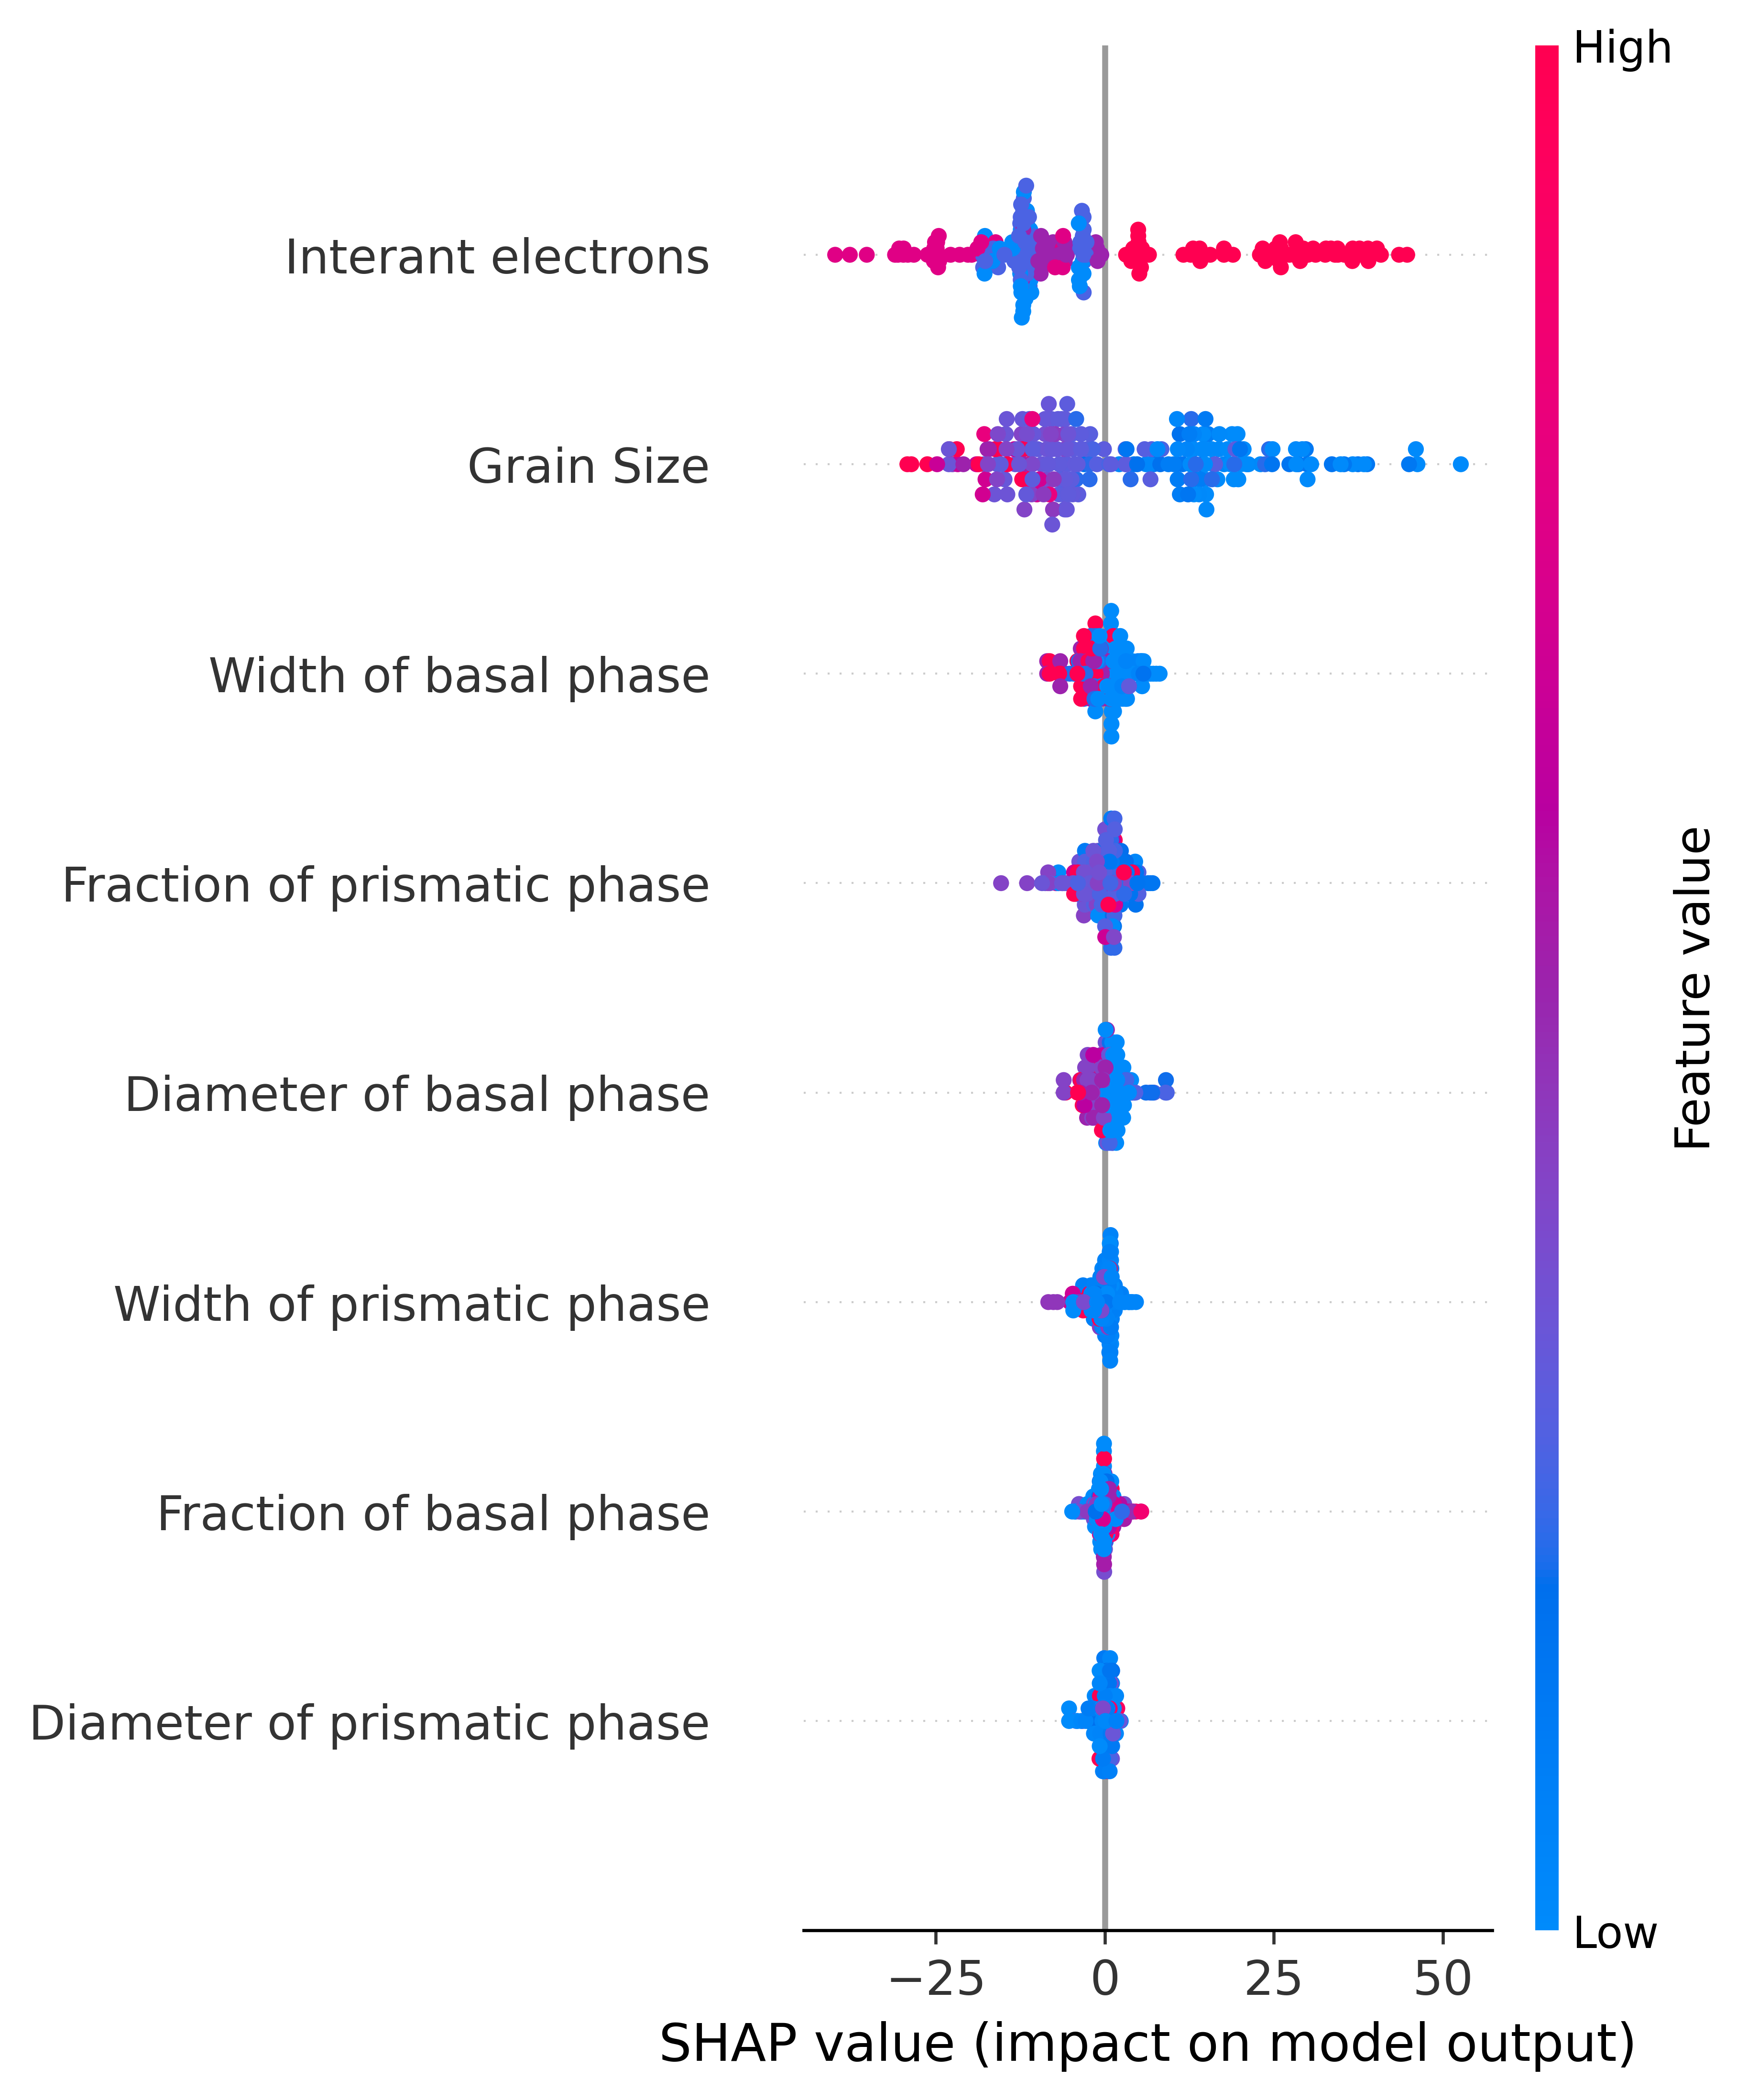

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import shap
from openpyxl import load_workbook
import matplotlib.pyplot as plt

problem_name = 'qf'
model_name = 'rf'
sheet_name = 'qf_21'
data_file = '20240607FULL_final.xlsx'
shap_output_path = f'final_model/{problem_name}/{model_name}_shap_results.xlsx'
model_save_path = f'final_model/{problem_name}/{model_name}'


# 创建文件夹
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# 读取数据
kl_data = pd.read_excel(data_file, index_col=0, sheet_name=sheet_name)
X = kl_data.iloc[:, :-2]
y = kl_data['屈服强度']

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 交叉验证配置
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 模型训练和评估
index = 0
with pd.ExcelWriter(shap_output_path, engine='openpyxl') as writer:
    # 初始化最终结果的DataFrame
    final_original_values_df = pd.DataFrame()
    final_shap_values_df = pd.DataFrame()
    feature_importance_list = []

    for train_index, test_index in skf.split(X, y_binned):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = RandomForestRegressor(random_state=60)
        model.fit(X_train, y_train)

        # joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # SHAP分析
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train)

        # 保存每个模型的原始值和SHAP值到单独的sheet
        original_sheet_name = f'Model_{index + 1}_Original'
        shap_sheet_name = f'Model_{index + 1}_SHAP'

        pd.DataFrame(X_train.values, columns=X_train.columns).to_excel(writer, sheet_name=original_sheet_name, index=False)
        pd.DataFrame(shap_values, columns=X_train.columns).to_excel(writer, sheet_name=shap_sheet_name, index=False)

        # 合并到最终结果DataFrame中
        original_values_df = pd.DataFrame(X_train.values, columns=X_train.columns)
        original_values_df['Model'] = model_name
        original_values_df['Fold'] = index + 1
        final_original_values_df = pd.concat([final_original_values_df, original_values_df], ignore_index=True)

        shap_values_df = pd.DataFrame(shap_values, columns=X_train.columns)
        shap_values_df['Model'] = model_name
        shap_values_df['Fold'] = index + 1
        final_shap_values_df = pd.concat([final_shap_values_df, shap_values_df], ignore_index=True)

        # 计算每个特征的SHAP值绝对值的均值
        feature_importance = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': np.abs(shap_values).mean(axis=0)
        }).sort_values(by='Importance', ascending=False)
        feature_importance['Model'] = model_name
        feature_importance['Fold'] = index + 1
        feature_importance_list.append(feature_importance)

        index += 1

    # 将所有折的特征重要性结果合并到一个DataFrame中
    feature_importance_df = pd.concat(feature_importance_list, ignore_index=True)

    # 写入最终的原始值和SHAP值sheet
    final_original_values_df.to_excel(writer, sheet_name='Final_Original_Values', index=False)
    final_shap_values_df.to_excel(writer, sheet_name='Final_SHAP_Values', index=False)
    feature_importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
print(f'SHAP results saved to {shap_output_path}')

# 读取最终的原始值和SHAP值数据
selected_features = ['Grain Size','Diameter of basal phase','Interant electrons',
                     'Width of basal phase', 'Fraction of basal phase', 'Diameter of prismatic phase',
                     'Width of prismatic phase', 'Fraction of prismatic phase']

final_original_values_df = pd.read_excel(shap_output_path, sheet_name='Final_Original_Values')[selected_features]
final_shap_values_df = pd.read_excel(shap_output_path, sheet_name='Final_SHAP_Values')[selected_features]

# 获取特定特征的原始值和SHAP值
original_values = final_original_values_df[selected_features]
shap_values = final_shap_values_df[selected_features]
plt.gcf().set_dpi(600)  # 设置dpi

# 使用shap.summary_plot函数绘制SHAP汇总图
shap.summary_plot(shap_values.values, original_values.values, feature_names=selected_features, show=False)
plt.gcf().set_size_inches(5, 8)  # 设置图像大小

plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小

# plt.savefig('YS_small_model.png')
plt.show()


In [ ]:
# 抗拉强度shap结果
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import shap
from openpyxl import load_workbook
import matplotlib.pyplot as plt
problem_name='kl'
model_name = 'rf'
sheet_name = 'kl_21'

data_file = '20240607FULL_final.xlsx'
shap_output_path = f'final_model/{problem_name}/{model_name}_shap_results.xlsx'
model_save_path = f'final_model/{problem_name}/{model_name}'

# 创建文件夹
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# 读取数据
kl_data = pd.read_excel(data_file, index_col=0, sheet_name=sheet_name)
X = kl_data.iloc[:, :-2]
y = kl_data['抗拉强度 （UTS）']

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 交叉验证配置
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 模型训练和评估
index = 0
with pd.ExcelWriter(shap_output_path, engine='openpyxl') as writer:
    # 初始化最终结果的DataFrame
    final_original_values_df = pd.DataFrame()
    final_shap_values_df = pd.DataFrame()

    for train_index, test_index in skf.split(X, y_binned):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = RandomForestRegressor(random_state=60)
        model.fit(X_train, y_train)

        # joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # SHAP分析
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train)

        # 保存每个模型的原始值和SHAP值到单独的sheet
        original_sheet_name = f'Model_{index + 1}_Original'
        shap_sheet_name = f'Model_{index + 1}_SHAP'

        pd.DataFrame(X_train.values, columns=X_train.columns).to_excel(writer, sheet_name=original_sheet_name, index=False)
        pd.DataFrame(shap_values, columns=X_train.columns).to_excel(writer, sheet_name=shap_sheet_name, index=False)

        # 合并到最终结果DataFrame中
        original_values_df = pd.DataFrame(X_train.values, columns=X_train.columns)
        original_values_df['Model'] = model_name
        original_values_df['Fold'] = index + 1
        final_original_values_df = pd.concat([final_original_values_df, original_values_df], ignore_index=True)

        shap_values_df = pd.DataFrame(shap_values, columns=X_train.columns)
        shap_values_df['Model'] = model_name
        shap_values_df['Fold'] = index + 1
        final_shap_values_df = pd.concat([final_shap_values_df, shap_values_df], ignore_index=True)

        index += 1
        # 写入最终的原始值和SHAP值sheet
    final_original_values_df.to_excel(writer, sheet_name='Final_Original_Values', index=False)
    final_shap_values_df.to_excel(writer, sheet_name='Final_SHAP_Values', index=False)
print(f'SHAP results saved to {shap_output_path}')


# 从Excel文件中读取最终的原始值和SHAP值数据
shap_output_path = 'final_model/kl/rf_shap_results.xlsx'
# 从Excel文件中读取最终的原始值和SHAP值数据
selected_features = ['Grain Size','Diameter of basal phase','Interant d electrons',
                               'Width of basal phase', 'Fraction of basal phase', 'Diameter of prismatic phase', 'Width of prismatic phase',
                               'Fraction of prismatic phase']  # 你希望绘制 SHAP summary plot 的特征列表
final_original_values_df = pd.read_excel(shap_output_path, sheet_name='Final_Original_Values')[selected_features]
final_shap_values_df = pd.read_excel(shap_output_path, sheet_name='Final_SHAP_Values')[selected_features]
display(final_original_values_df)
# 选择要绘制的特征名称
feature_to_plot = selected_features

# 获取特定特征的原始值和SHAP值
original_values = final_original_values_df[feature_to_plot]
shap_values = final_shap_values_df[feature_to_plot]
plt.gcf().set_dpi(600)  # 设置dpi

# 使用shap.summary_plot函数绘制SHAP汇总图
shap.summary_plot(shap_values.values, original_values.values, feature_names=feature_to_plot,  show=False)
plt.gcf().set_size_inches(5, 8)  # 设置图像大小

plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小
plt.savefig('TS_samll_model.png')
plt.show()

The least populated class in y has only 2 members, which is less than n_splits=5.


SHAP results saved to final_model/kl/rf_shap_results.xlsx


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


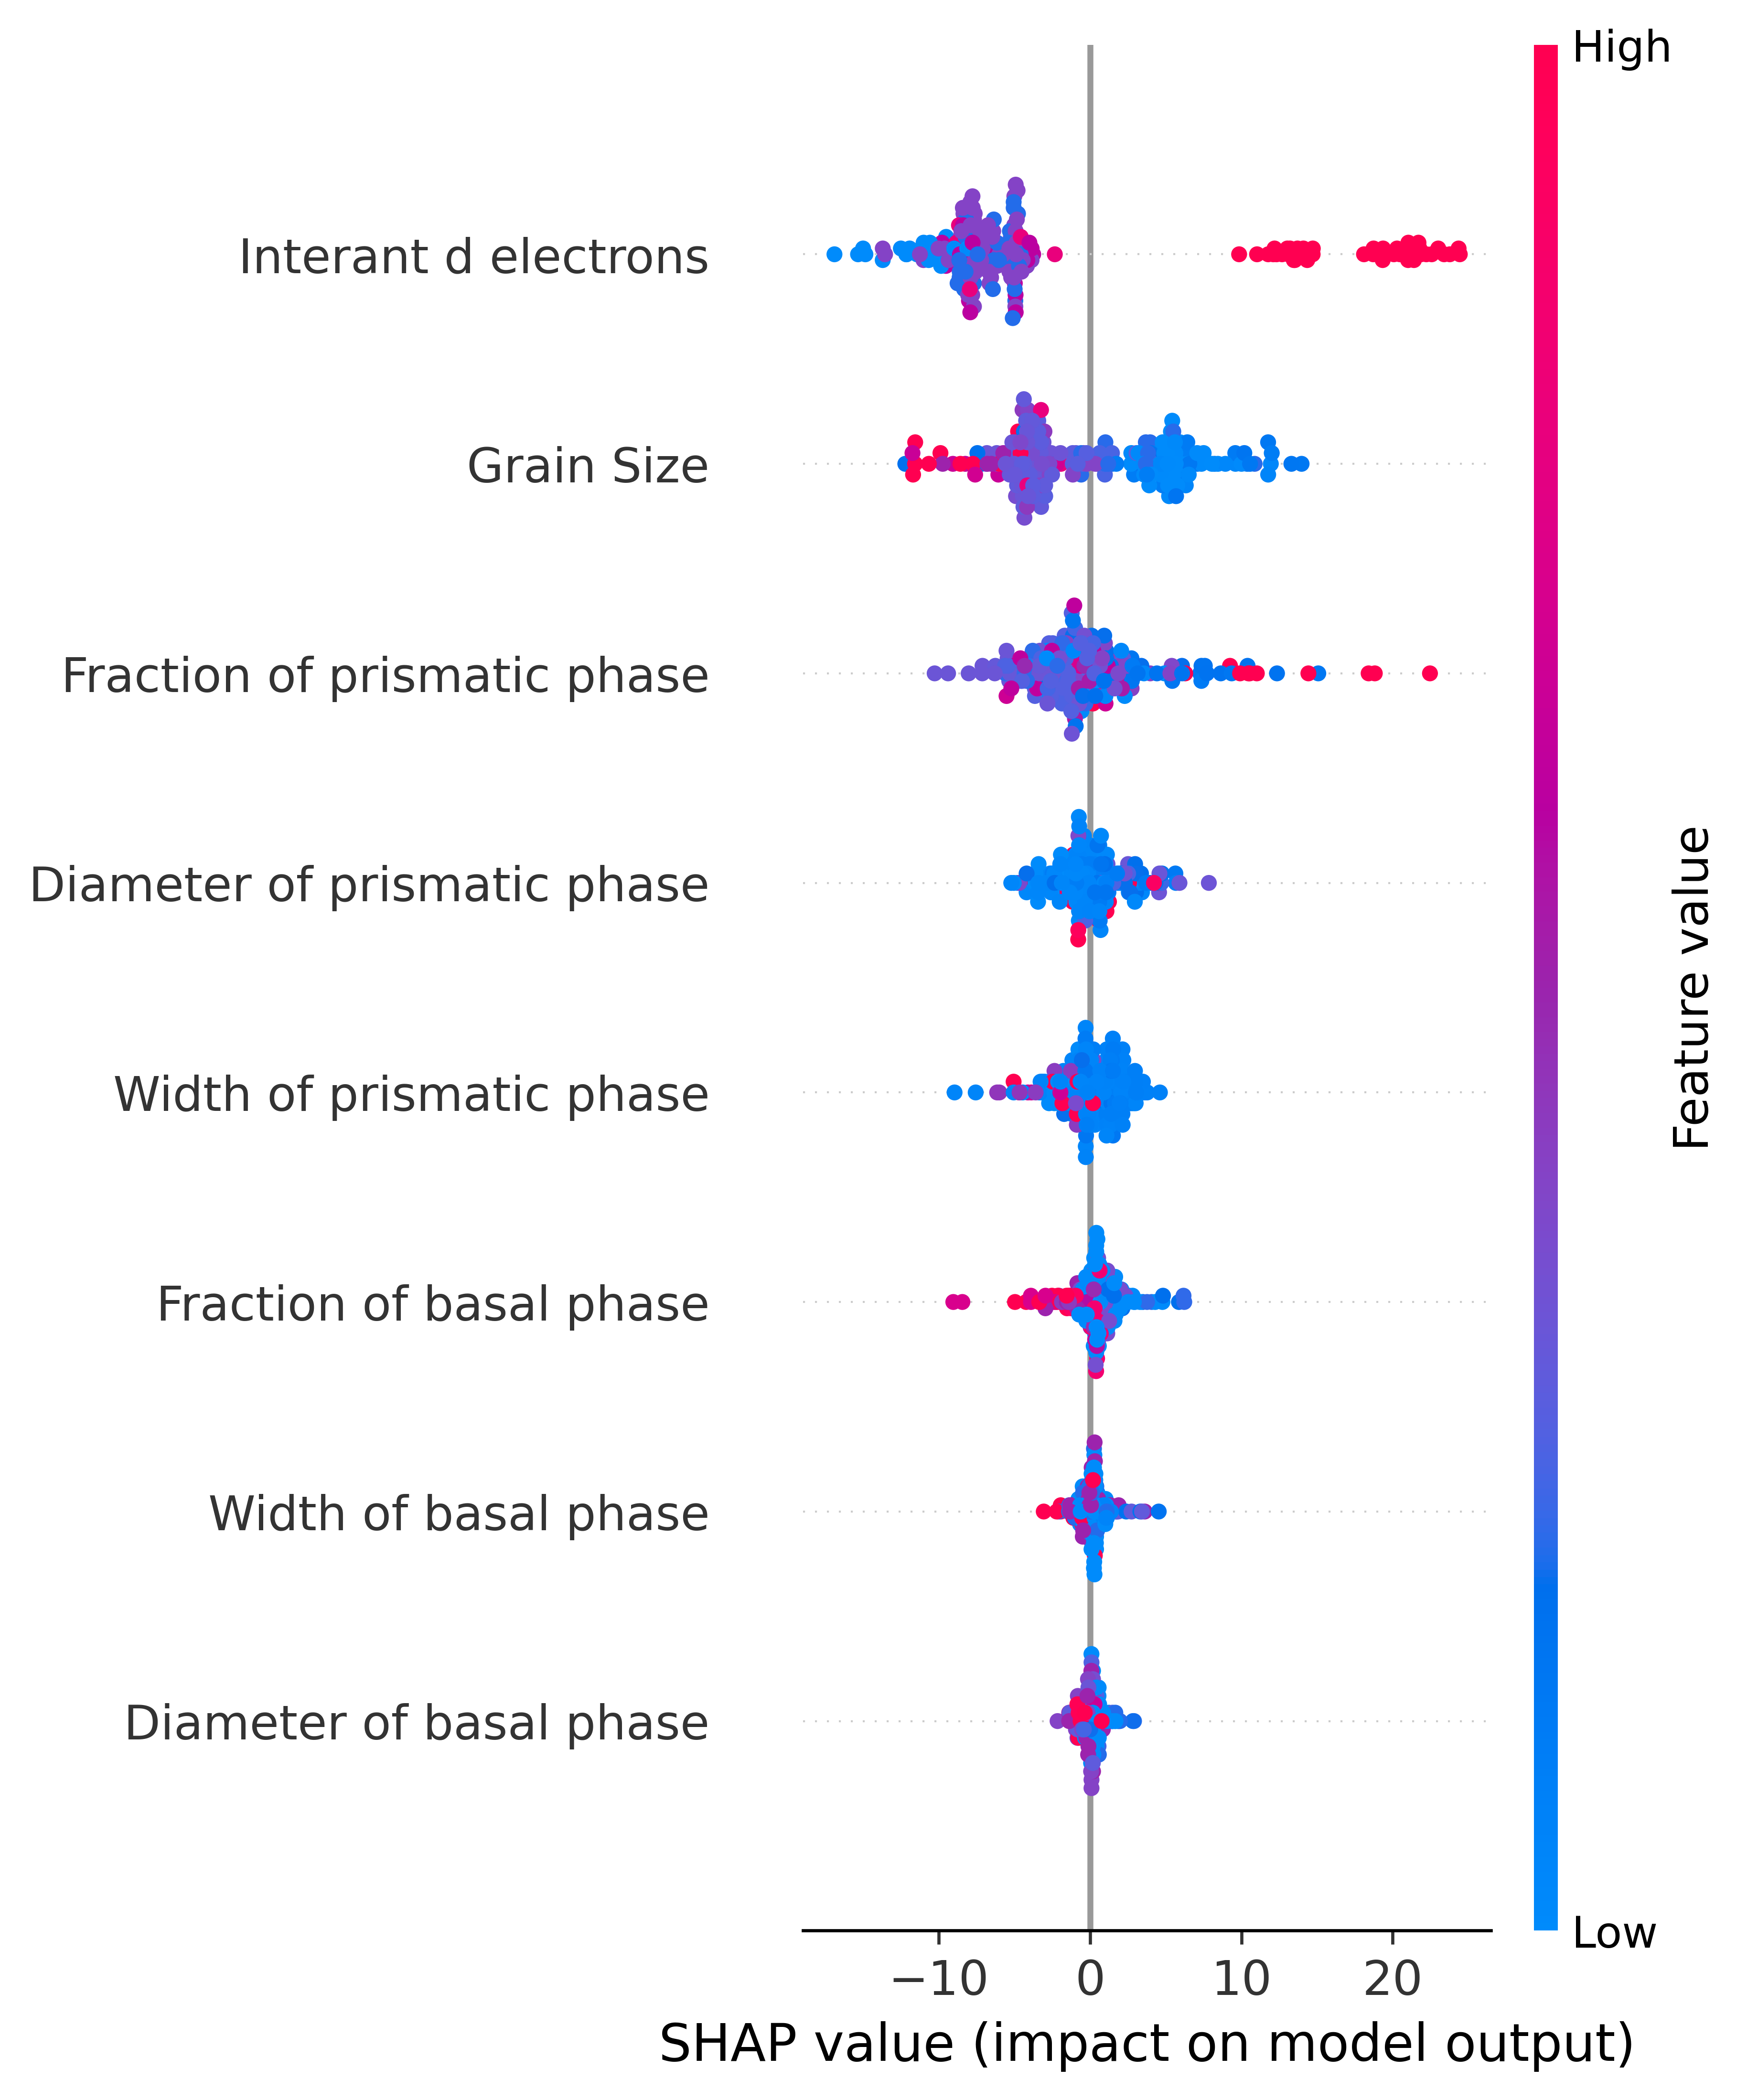

In [4]:
# 抗拉强度shap结果
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import shap
from openpyxl import load_workbook
import matplotlib.pyplot as plt
problem_name='kl'
model_name = 'rf'
sheet_name = 'kl_21'

data_file = '20240607FULL_final.xlsx'
shap_output_path = f'final_model/{problem_name}/{model_name}_shap_results.xlsx'
model_save_path = f'final_model/{problem_name}/{model_name}'

# 创建文件夹
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# 读取数据
kl_data = pd.read_excel(data_file, sheet_name=sheet_name)
X = kl_data.iloc[:, :-2]
y = kl_data['抗拉强度 （UTS）']

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 交叉验证配置
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 模型训练和评估
index = 0
with pd.ExcelWriter(shap_output_path, engine='openpyxl') as writer:
    # 初始化最终结果的DataFrame
    final_original_values_df = pd.DataFrame()
    final_shap_values_df = pd.DataFrame()
    feature_importance_list = []

    for train_index, test_index in skf.split(X, y_binned):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = RandomForestRegressor(random_state=60)
        model.fit(X_train, y_train)

        # joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')

        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # SHAP分析
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train)

        # 保存每个模型的原始值和SHAP值到单独的sheet
        original_sheet_name = f'Model_{index + 1}_Original'
        shap_sheet_name = f'Model_{index + 1}_SHAP'

        pd.DataFrame(X_train.values, columns=X_train.columns).to_excel(writer, sheet_name=original_sheet_name, index=False)
        pd.DataFrame(shap_values, columns=X_train.columns).to_excel(writer, sheet_name=shap_sheet_name, index=False)

        # 合并到最终结果DataFrame中
        original_values_df = pd.DataFrame(X_train.values, columns=X_train.columns)
        original_values_df['Model'] = model_name
        original_values_df['Fold'] = index + 1
        final_original_values_df = pd.concat([final_original_values_df, original_values_df], ignore_index=True)

        shap_values_df = pd.DataFrame(shap_values, columns=X_train.columns)
        shap_values_df['Model'] = model_name
        shap_values_df['Fold'] = index + 1
        final_shap_values_df = pd.concat([final_shap_values_df, shap_values_df], ignore_index=True)

        # 计算每个特征的SHAP值绝对值的均值
        feature_importance = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': np.abs(shap_values).mean(axis=0)
        }).sort_values(by='Importance', ascending=False)
        feature_importance['Model'] = model_name
        feature_importance['Fold'] = index + 1
        feature_importance_list.append(feature_importance)

        index += 1

    # 将所有折的特征重要性结果合并到一个DataFrame中
    feature_importance_df = pd.concat(feature_importance_list, ignore_index=True)

    # 写入最终的原始值和SHAP值sheet
    final_original_values_df.to_excel(writer, sheet_name='Final_Original_Values', index=False)
    final_shap_values_df.to_excel(writer, sheet_name='Final_SHAP_Values', index=False)
    feature_importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
print(f'SHAP results saved to {shap_output_path}')

# 读取最终的原始值和SHAP值数据
selected_features = ['Grain Size','Diameter of basal phase','Interant d electrons',
                     'Width of basal phase', 'Fraction of basal phase', 'Diameter of prismatic phase',
                     'Width of prismatic phase', 'Fraction of prismatic phase']

final_original_values_df = pd.read_excel(shap_output_path, sheet_name='Final_Original_Values')[selected_features]
final_shap_values_df = pd.read_excel(shap_output_path, sheet_name='Final_SHAP_Values')[selected_features]

# 获取特定特征的原始值和SHAP值
original_values = final_original_values_df[selected_features]
shap_values = final_shap_values_df[selected_features]
plt.gcf().set_dpi(600)  # 设置dpi

# 使用shap.summary_plot函数绘制SHAP汇总图
shap.summary_plot(shap_values.values, original_values.values, feature_names=selected_features, show=False)
plt.gcf().set_size_inches(5, 8)  # 设置图像大小

plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小

# plt.savefig('YS_small_model.png')
plt.show()


C:\Users\acer-pc\AppData\Local\Temp\ipykernel_4608\1487069067.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_original_values = pd.DataFrame(index=original_values_kl.index, columns=all_features).fillna(0)
C:\Users\acer-pc\AppData\Local\Temp\ipykernel_4608\1487069067.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_shap_values = pd.DataFrame(index=shap_values_kl.index, columns=all_features).fillna(0)


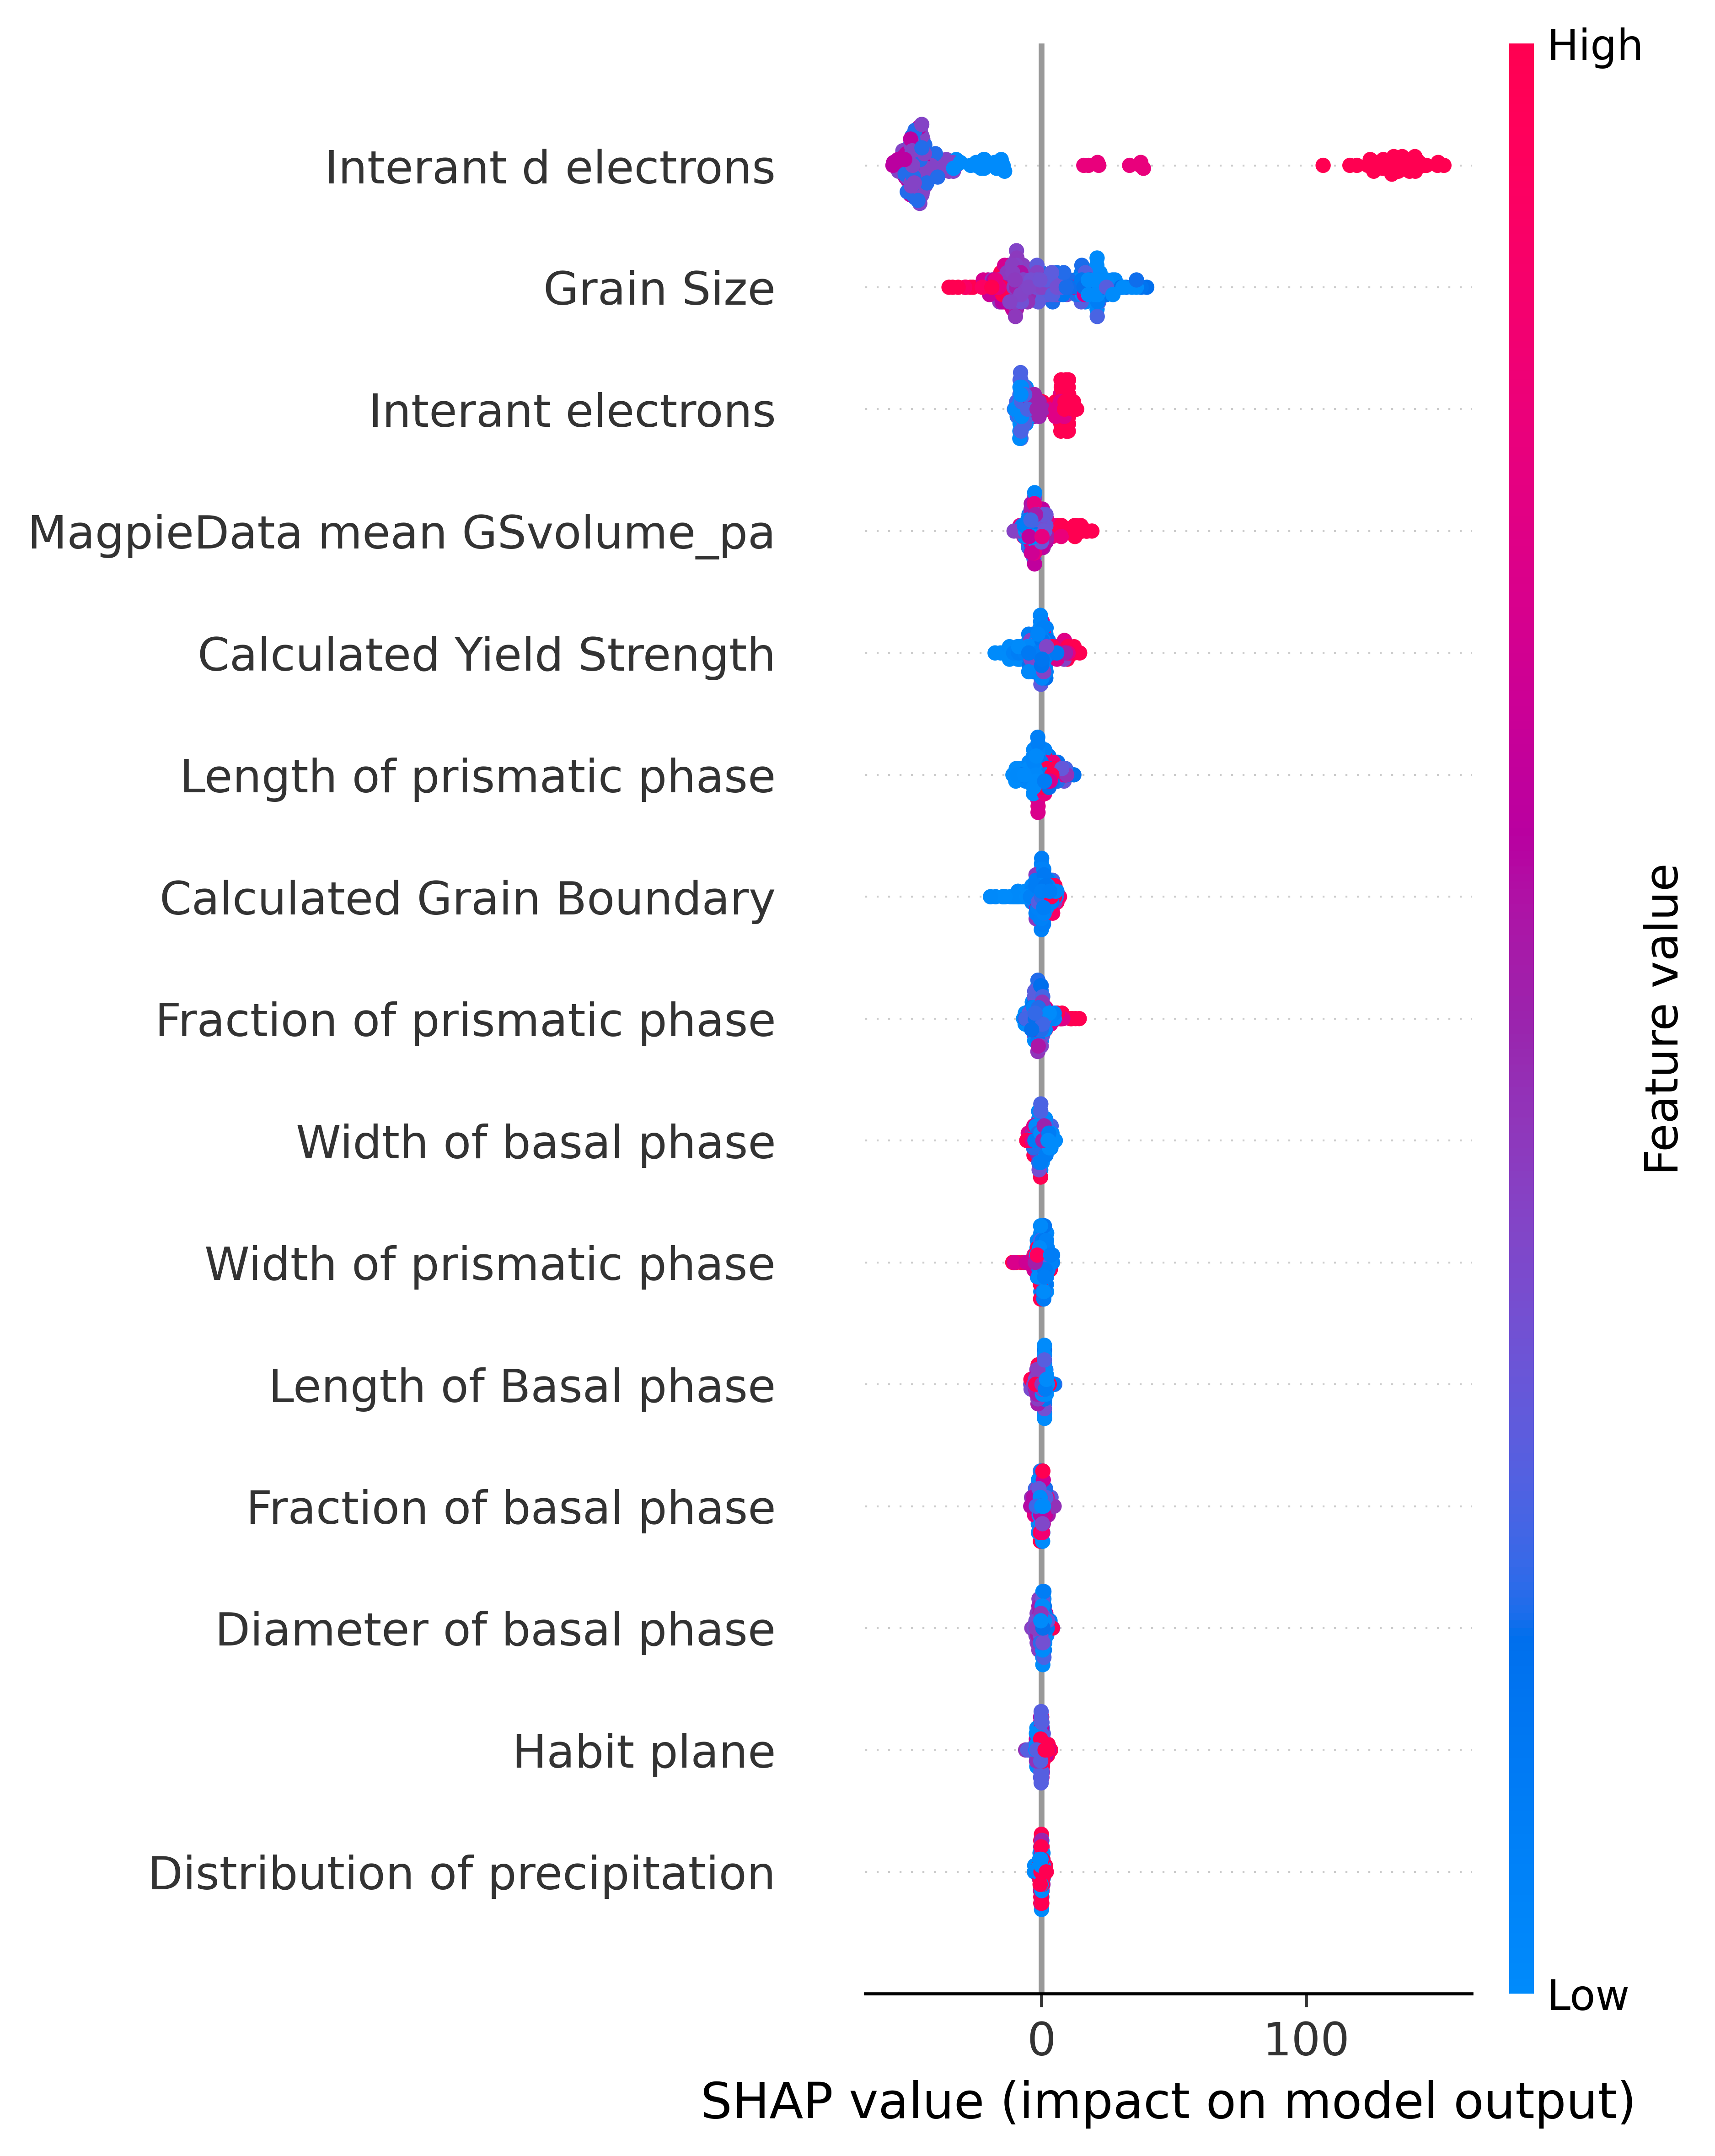

In [7]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# 读取抗拉强度数据
shap_output_path_kl = 'final_model/kl/rf_shap_results.xlsx'
final_original_values_kl = pd.read_excel(shap_output_path_kl, sheet_name='Final_Original_Values')
final_shap_values_kl = pd.read_excel(shap_output_path_kl, sheet_name='Final_SHAP_Values')

# 读取屈服强度数据，并删除不需要的列
shap_output_path_qf = 'final_model/qf/rf_shap_results.xlsx'
final_original_values_qf = pd.read_excel(shap_output_path_qf, sheet_name='Final_Original_Values').drop(columns=['MagpieData range MeltingT', 'MagpieData maximum MeltingT'])
final_shap_values_qf = pd.read_excel(shap_output_path_qf, sheet_name='Final_SHAP_Values').drop(columns=['MagpieData range MeltingT', 'MagpieData maximum MeltingT'])

# 获取特征名称
features_kl = final_original_values_kl.columns[:-2]
features_qf = final_original_values_qf.columns[:-2]

# 获取原始值和SHAP值
original_values_kl = final_original_values_kl[features_kl]
shap_values_kl = final_shap_values_kl[features_kl]

original_values_qf = final_original_values_qf[features_qf]
shap_values_qf = final_shap_values_qf[features_qf]

# 合并特征名称
all_features = list(set(features_kl).union(set(features_qf)))

# 初始化空的DataFrame来存储合并后的原始值和SHAP值
combined_original_values = pd.DataFrame(index=original_values_kl.index, columns=all_features).fillna(0)
combined_shap_values = pd.DataFrame(index=shap_values_kl.index, columns=all_features).fillna(0)

# 对共同特征取平均，对于独特特征保留原始值和SHAP值
for feature in all_features:
    if feature in original_values_kl.columns and feature in original_values_qf.columns:
        combined_original_values[feature] = (original_values_kl[feature] + original_values_qf[feature]) / 2
        combined_shap_values[feature] = (shap_values_kl[feature] + shap_values_qf[feature]) / 2
    elif feature in original_values_kl.columns:
        combined_original_values[feature] = original_values_kl[feature]
        combined_shap_values[feature] = shap_values_kl[feature]
    else:
        combined_original_values[feature] = original_values_qf[feature]
        combined_shap_values[feature] = shap_values_qf[feature]

# 绘制合并后的SHAP summary_plot图
plt.gcf().set_dpi(600)  # 设置dpi

shap.summary_plot(combined_shap_values.values, combined_original_values.values, feature_names=all_features, show=False)
plt.gcf().set_size_inches(5, 8)  # 设置图像大小

plt.xticks(fontsize=12)  # 设置x轴标签字体大小
plt.yticks(fontsize=12)  # 设置y轴标签字体大小

plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import shap
from openpyxl import load_workbook

problem_name = 'qf'
model_name = 'rf'
sheet_name = 'qf_16'
data_file = '20240607FULL_final.xlsx'
shap_output_path = f'final_model/{problem_name}/{model_name}_shap_results.xlsx'
model_save_path = f'final_model/{problem_name}/{model_name}'

# 创建文件夹
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# 读取数据
kl_data = pd.read_excel(data_file, index_col=0, sheet_name=sheet_name)
X = kl_data.iloc[:, :-2]
y = kl_data['屈服强度']

# 分箱
bins = np.linspace(y.min(), y.max(), 11)
y_binned = np.digitize(y, bins)

# 交叉验证配置
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)

# 结果存储
r2_scores = []
mape_scores = []
mae_scores = []
results = []
overall_shap_df = pd.DataFrame()
feature_shap_dfs = {feature: pd.DataFrame(columns=['Model', 'Fold', 'Original Value', 'SHAP Value']) for feature in X.columns}

# 模型训练和评估
index = 0
for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(random_state=60)
    model.fit(X_train, y_train)

    joblib.dump(model, f'{model_save_path}/{model_name}_{index}.pkl')
    
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)
    
    results.append({
        'Fold': index + 1,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    })
    
    # SHAP分析
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    shap.initjs()

    # 测试数据与SHAP值DataFrame
    df0 = pd.DataFrame(np.array(X_train), columns=X_train.columns)
    df_shap_values = pd.DataFrame(np.array(shap_values), columns=X_train.columns)

    # 保存每个特征的SHAP值
    for feature in X.columns:
        feature_shap_df = feature_shap_dfs[feature]
        temp_df = pd.DataFrame({
            'Model': [model_name] * len(X_train),
            'Fold': [index + 1] * len(X_train),
            'Original Value': X_train[feature].values,
            'SHAP Value': shap_values[:, X.columns.get_loc(feature)]
        })
        feature_shap_dfs[feature] = pd.concat([feature_shap_df, temp_df])
        
        # 更新 overall_shap_df
        temp_shap_importance_df = pd.DataFrame({
            'Feature Name': [feature] * len(X_train),
            'SHAP Value': shap_values[:, X.columns.get_loc(feature)],
            'Model': [f'{model_name}_{index + 1}'] * len(X_train)
        })
        overall_shap_df = pd.concat([overall_shap_df, temp_shap_importance_df])

    index += 1

# 计算平均SHAP值
overall_shap_importance = overall_shap_df.groupby('Feature Name')['SHAP Value'].mean().reset_index().sort_values(by='SHAP Value', ascending=False)

# 保存综合的SHAP特征重要性
with pd.ExcelWriter(shap_output_path, engine='openpyxl') as writer:
    overall_shap_importance.to_excel(writer, sheet_name=f'{problem_name}_{model_name}_overall_shap_importance', index=False)

# 保存每个特征的SHAP值到新的Excel文件
feature_shap_output_path = f'final_model/{problem_name}/{model_name}_feature_shap_values.xlsx'
with pd.ExcelWriter(feature_shap_output_path, engine='openpyxl') as writer:
    for feature, feature_shap_df in feature_shap_dfs.items():
        feature_shap_df.to_excel(writer, sheet_name=feature, index=False)

# 保存交叉验证结果
mean_r2 = np.mean(r2_scores)
mean_mae = np.mean(mae_scores)
mean_mape = np.mean(mape_scores)

results.append({
    'Fold': 'Mean',
    'MAE': mean_mae,
    'MAPE': mean_mape,
    'R2': mean_r2
})

results_df = pd.DataFrame(results)
results_df.to_excel(f'{model_save_path}/{model_name}_cross_validation_results.xlsx', index=False)

print(f"Mean Absolute Percentage Error: {mean_mape}")
print(f"Mean Absolute Error: {mean_mae}")
print(f"R^2 Score: {mean_r2}")

print("SHAP importance results saved successfully!")
